# Homework 9 APPM 4600
## Problem 1
![p1](Images/homework%209-p1.jpeg)

## Problem 2
### Part a)

In [15]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('../Data/HW09_multivariate_data.csv', header=None)
y = data[0].values
x1 = data[1].values
x2 = data[2].values
x3 = data[3].values

# Create the matrix for polynomial regression
X = np.column_stack((np.ones(len(x1)), x1, x2, x3, x1*x2, x1*x3, x2*x3, x1**2, x2**2, x3**2))
# Perform least squares regression to find coefficients
coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
# Round coefficients to two decimal places
coefficients = np.round(coefficients, 2)
# Print the polynomial
print(f"Polynomial: p(x) = {coefficients[0]} + {coefficients[1]}x1 + {coefficients[2]}x2 + {coefficients[3]}x3 + {coefficients[4]}x1x2 + {coefficients[5]}x1x3 + {coefficients[6]}x2x3 + {coefficients[7]}x1^2 + {coefficients[8]}x2^2 + {coefficients[9]}x3^2")


Polynomial: p(x) = 10.03 + 0.06x1 + -0.0x2 + -4.17x3 + 3.4x1x2 + 0.0x1x3 + -6.7x2x3 + -1.07x1^2 + -0.0x2^2 + 2.33x3^2


### Part b)
If $d = 4194304 \gg n$, $\begin{pmatrix} n+d \\ n\end{pmatrix} = \frac{(n+d)!}{n!d!} = \frac{(d+1)(d+2)\dots (d+n)}{n!} = \frac{d^n (1+1/d)(1+2/d) \dots (1+n/d)}{n!}$ but since $d\gg n$, each $k/d \ll 1$, so $(1+1/d)\dots (1+n/d)\approx 1$, thus the leading approximation is $\frac{d^n}{n!}$ 
Then

| Dimension $d$ | Degree $n$ | Number of coefficients |
|---------|--------|--------|
| 3 | 10 | 286 |
| 100 | 4 | 4,166,667 |
| 10,000 | 3 | 166,666,666,667 |
| $2^{22} | 2 | 8,796,093,022,208 |


## Problem 3 Continuous $L^2$ approximation
Let $f(x) = \sin(2.5x)$ on $[-1,3]$. Compute
- the best $L^2$ norm approximation of $f$ wrt $||f||_2^2$
- the best weighed $L^2$ norm approximation of f with weight $w(x) = \tilde w(\frac 1 2(x-1))$ for $\tilde w(x) = \frac{1}{\sqrt{1-x^2}}$

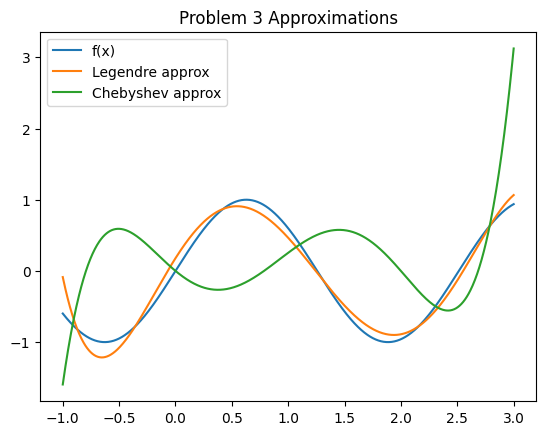

Legendre (monomial):
[ 0.46 -3.47 -4.38 11.46  4.41 -7.41]
Chebyshev (monomial):
[  0.25   2.36  -1.53 -12.57   2.04  12.57]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Legendre, Chebyshev, Polynomial

# function
f = lambda x: np.sin(2.5*x)

# domain
a, b = -1, 3

# map x ∈ [-1,3] → t ∈ [-1,1]
def x_to_t(x):
    return (2*x - (b+a)) / (b-a)

def t_to_x(t):
    return 0.5*(b-a)*t + 0.5*(b+a)

# sample for projection
N = 1000
x = np.linspace(a, b, N)
t = x_to_t(x)
fx = f(x)

# -------------------
# (a) Legendre (unweighted L2)
# -------------------
leg_coefs = []

from scipy.integrate import simpson
for n in range(6):
    Pn = Legendre.basis(n)
    Pn_vals = Pn(t)

    # inner product (numerical integration)
    num = simpson(fx * Pn_vals, x)
    den = simpson(Pn_vals**2, x)

    leg_coefs.append(num / den)

# build polynomial
P_leg = sum(c * Legendre.basis(i) for i, c in enumerate(leg_coefs))
P_leg_monomial = P_leg.convert(kind=Polynomial)

# -------------------
# (b) Chebyshev (weighted)
# -------------------

cheb_coefs = []

for n in range(6):
    Tn = Chebyshev.basis(n)
    Tn_vals = Tn(t)

    weight = 1 / np.sqrt(1 - t**2 + 1e-12)  # avoid divide by zero

    num = simpson(fx * Tn_vals * weight, x)
    den = simpson(Tn_vals**2 * weight, x)

    cheb_coefs.append(num / den)

P_cheb = sum(c * Chebyshev.basis(i) for i, c in enumerate(cheb_coefs))
P_cheb_monomial = P_cheb.convert(kind=Polynomial)

# -------------------
# Plot
# -------------------
plt.figure()
plt.plot(x, fx, label="f(x)")
plt.plot(x, P_leg(t), label="Legendre approx")
plt.plot(x, P_cheb(t), label="Chebyshev approx")
plt.legend()
plt.title("Problem 3 Approximations")
plt.show()

# print coefficients (monomial basis)
print("Legendre (monomial):")
print(np.round(P_leg_monomial.coef, 2))

print("Chebyshev (monomial):")
print(np.round(P_cheb_monomial.coef, 2))

## Problem 4: Continuous $L^2$ vs discrete $\ell^2$ approximation
Do the same as above and do a discrete approx with no weights and 100 equally spaced dataponits.

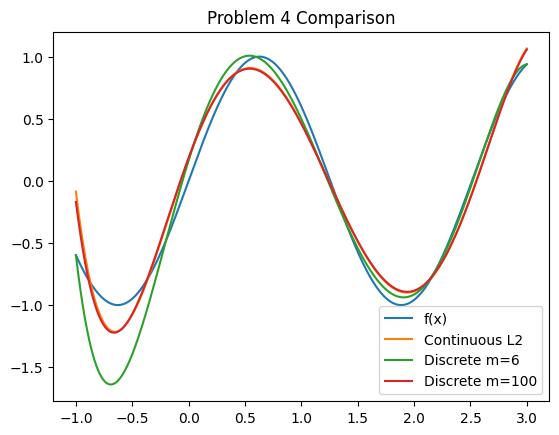

In [17]:
from numpy.polynomial import Legendre

# sample sizes
m_values = [6, 100]

plt.figure()
plt.plot(x, fx, label="f(x)")
plt.plot(x, P_leg(t), label="Continuous L2")

for m in m_values:
    x_data = np.linspace(a, b, m)
    y_data = f(x_data)

    # fit degree 5 polynomial
    fit = Legendre.fit(x_data, y_data, deg=5, domain=[a, b])

    # evaluate
    y_fit = fit(x)

    plt.plot(x, y_fit, label=f"Discrete m={m}")

plt.legend()
plt.title("Problem 4 Comparison")
plt.show()

As $m\to \infty$, the discrete least squares does converge do the continuous $L^2$ approximation. This comes from the fact that the Riemann sum becomes the integral.

With the Chebyshev case, the weight blows up at the endpoints, and convergence is slow or can be wrong.